# 🫀 Cardiovascular Disease Risk Prediction
### A Machine Learning Classification Study
**Author:** Zoeb Ali Khan | M.Sc. Data Science · Universität Bielefeld  
**Dataset:** CDC BRFSS 2022 Survey · 308,854 records · 18 features  

---
**Objective:** Predict the likelihood of cardiovascular disease using behavioral and clinical risk factors from the CDC's annual health survey. This notebook covers end-to-end pipeline development: EDA → preprocessing → model training → evaluation → feature analysis.

## 0. Environment Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import resample
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, roc_curve
)

# Plotting style
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d2e',
    'axes.edgecolor':   '#2d3154',
    'axes.labelcolor':  '#c8cde8',
    'xtick.color':      '#8891b8',
    'ytick.color':      '#8891b8',
    'text.color':       '#c8cde8',
    'grid.color':       '#2d3154',
    'grid.alpha':       0.5,
    'font.family':      'DejaVu Sans',
    'font.size':        11,
})

ACCENT   = ['#7c83fd', '#f7706d', '#4ecdc4', '#ffe66d']
PALETTE  = ['#7c83fd', '#f7706d']

print("✓ Libraries loaded successfully")

✓ Libraries loaded successfully


## 1. Data Loading & Initial Inspection

The dataset is derived from the CDC **Behavioral Risk Factor Surveillance System (BRFSS) 2022** — a nationally representative telephone survey of U.S. adults on health behaviors, chronic conditions, and preventive services.

In [3]:
df = pd.read_csv('CVD_cleaned.csv')

print(f"Dataset shape   : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory usage    : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"Missing values  : {df.isnull().sum().sum()}")
print(f"\nTarget distribution:")
print(df['Heart_Disease'].value_counts())
print(f"\nClass imbalance ratio: {df['Heart_Disease'].value_counts()['No'] / df['Heart_Disease'].value_counts()['Yes']:.1f}:1 (No:Yes)")
df.head()

Dataset shape   : 66,133 rows × 19 columns
Memory usage    : 46.3 MB
Missing values  : 17

Target distribution:
Heart_Disease
No     61129
Yes     5003
Name: count, dtype: int64

Class imbalance ratio: 12.2:1 (No:Yes)


,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,Poor,Within the past 2 years,No,No,No,No,No,No,Yes,Female,70-74,150.0,32.66,14.54,Yes,0.0,30.0,16.0,12.0
1,Very Good,Within the past year,No,Yes,No,No,No,Yes,No,Female,70-74,165.0,77.11,28.29,No,0.0,30.0,0.0,4.0
2,Very Good,Within the past year,Yes,No,No,No,No,Yes,No,Female,60-64,163.0,88.45,33.47,No,4.0,12.0,3.0,16.0
3,Poor,Within the past year,Yes,Yes,No,No,No,Yes,No,Male,75-79,180.0,93.44,28.73,No,0.0,30.0,30.0,8.0
4,Good,Within the past year,No,No,No,No,No,No,No,Male,80+,191.0,88.45,24.37,Yes,0.0,8.0,4.0,0.0


## 2. Exploratory Data Analysis (EDA)

### 2.1 Target Variable — Class Imbalance

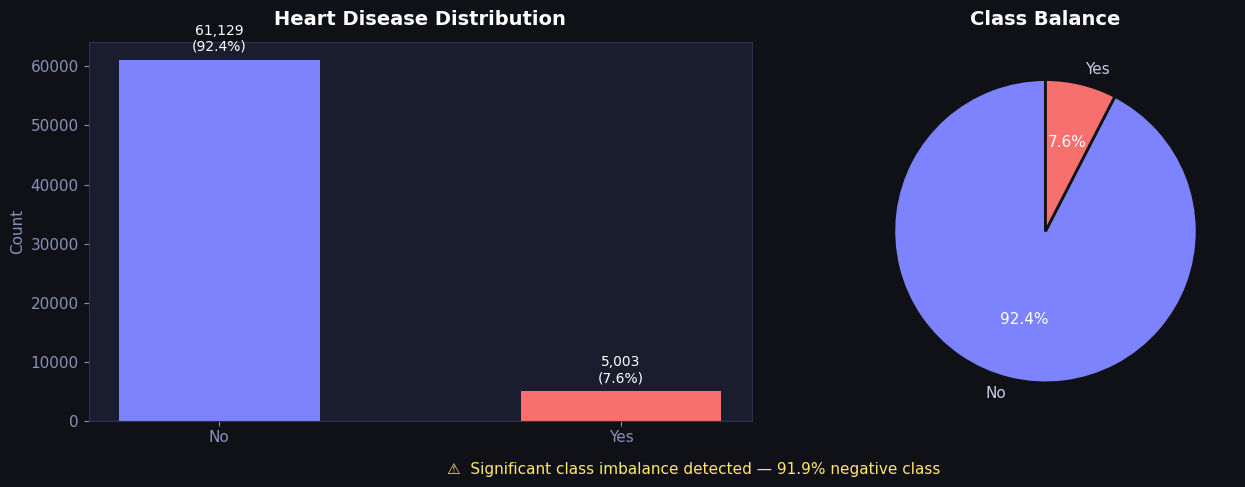

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0f1117')

counts = df['Heart_Disease'].value_counts()

# Bar chart
bars = axes[0].bar(counts.index, counts.values, color=PALETTE, width=0.5, edgecolor='none')
axes[0].set_title('Heart Disease Distribution', fontsize=14, fontweight='bold', color='white', pad=12)
axes[0].set_ylabel('Count', color='#8891b8')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1500,
                 f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', color='white', fontsize=10)

# Pie
wedges, _, autotexts = axes[1].pie(
    counts.values, labels=counts.index, colors=PALETTE,
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(edgecolor='#0f1117', linewidth=2)
)
for at in autotexts:
    at.set_color('white'); at.set_fontsize(11)
axes[1].set_title('Class Balance', fontsize=14, fontweight='bold', color='white', pad=12)

plt.suptitle('⚠  Significant class imbalance detected — 91.9% negative class',
             color='#ffe66d', fontsize=11, y=0)
plt.tight_layout()
plt.show()

### 2.2 Lifestyle & Health Factor Distributions

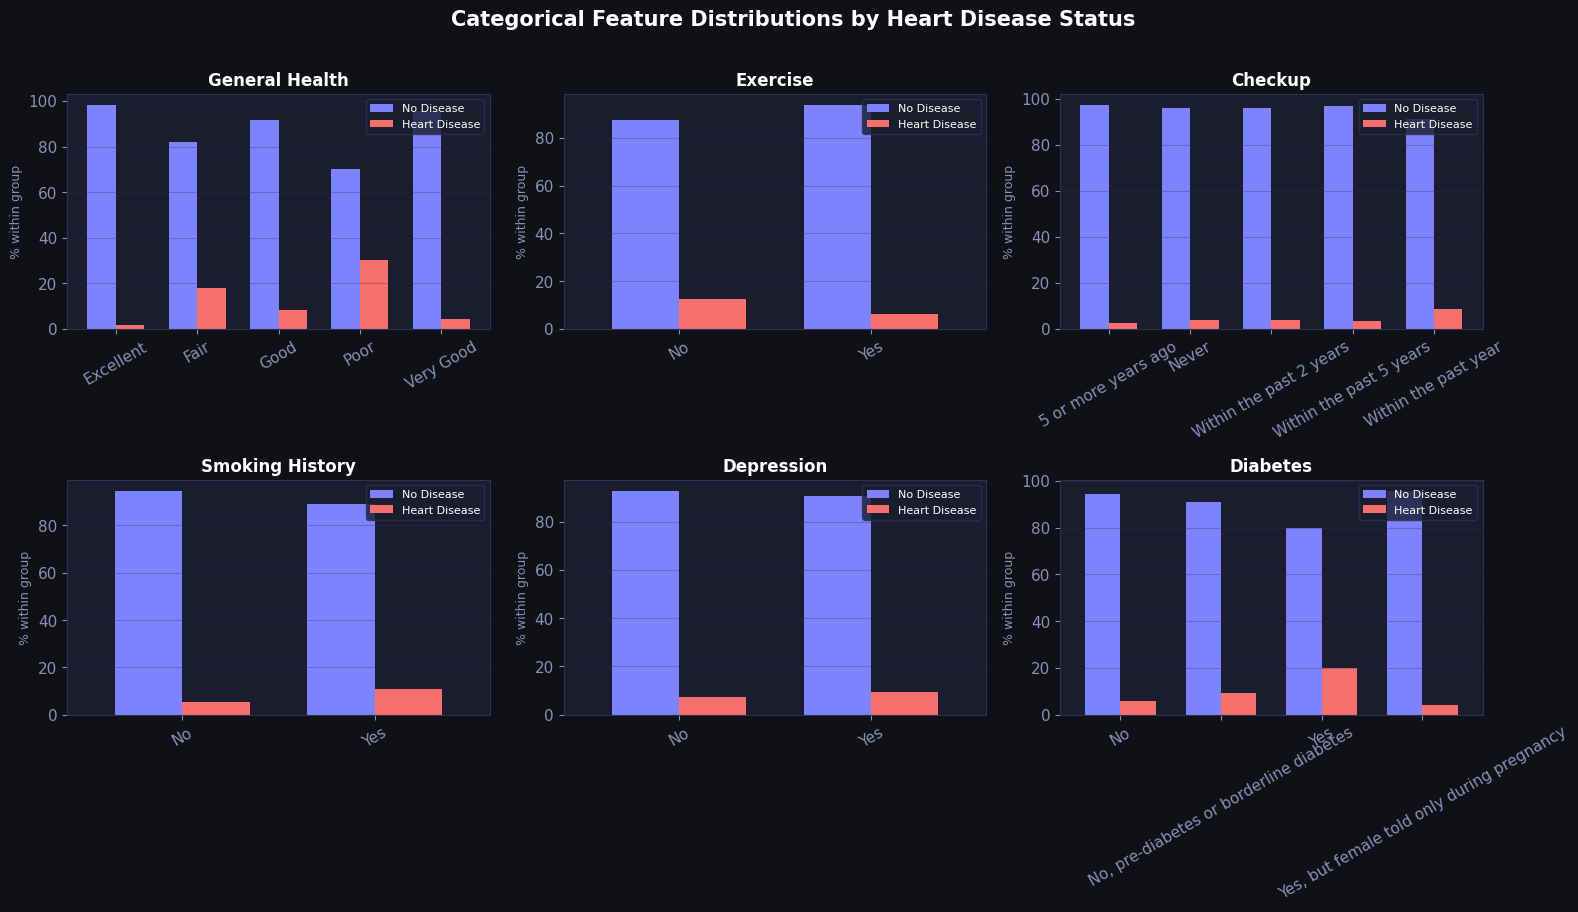

In [5]:
cat_cols = ['General_Health', 'Exercise', 'Checkup', 'Smoking_History', 'Depression', 'Diabetes']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.patch.set_facecolor('#0f1117')
fig.suptitle('Categorical Feature Distributions by Heart Disease Status',
             fontsize=15, fontweight='bold', color='white', y=1.01)

axes = axes.flatten()
for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df['Heart_Disease'], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[i], color=PALETTE, edgecolor='none', width=0.7)
    axes[i].set_title(col.replace('_', ' '), color='white', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('% within group', color='#8891b8', fontsize=9)
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(['No Disease', 'Heart Disease'], fontsize=8,
                   facecolor='#1a1d2e', edgecolor='#2d3154', labelcolor='white')
    axes[i].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### 2.3 Continuous Features vs. Heart Disease

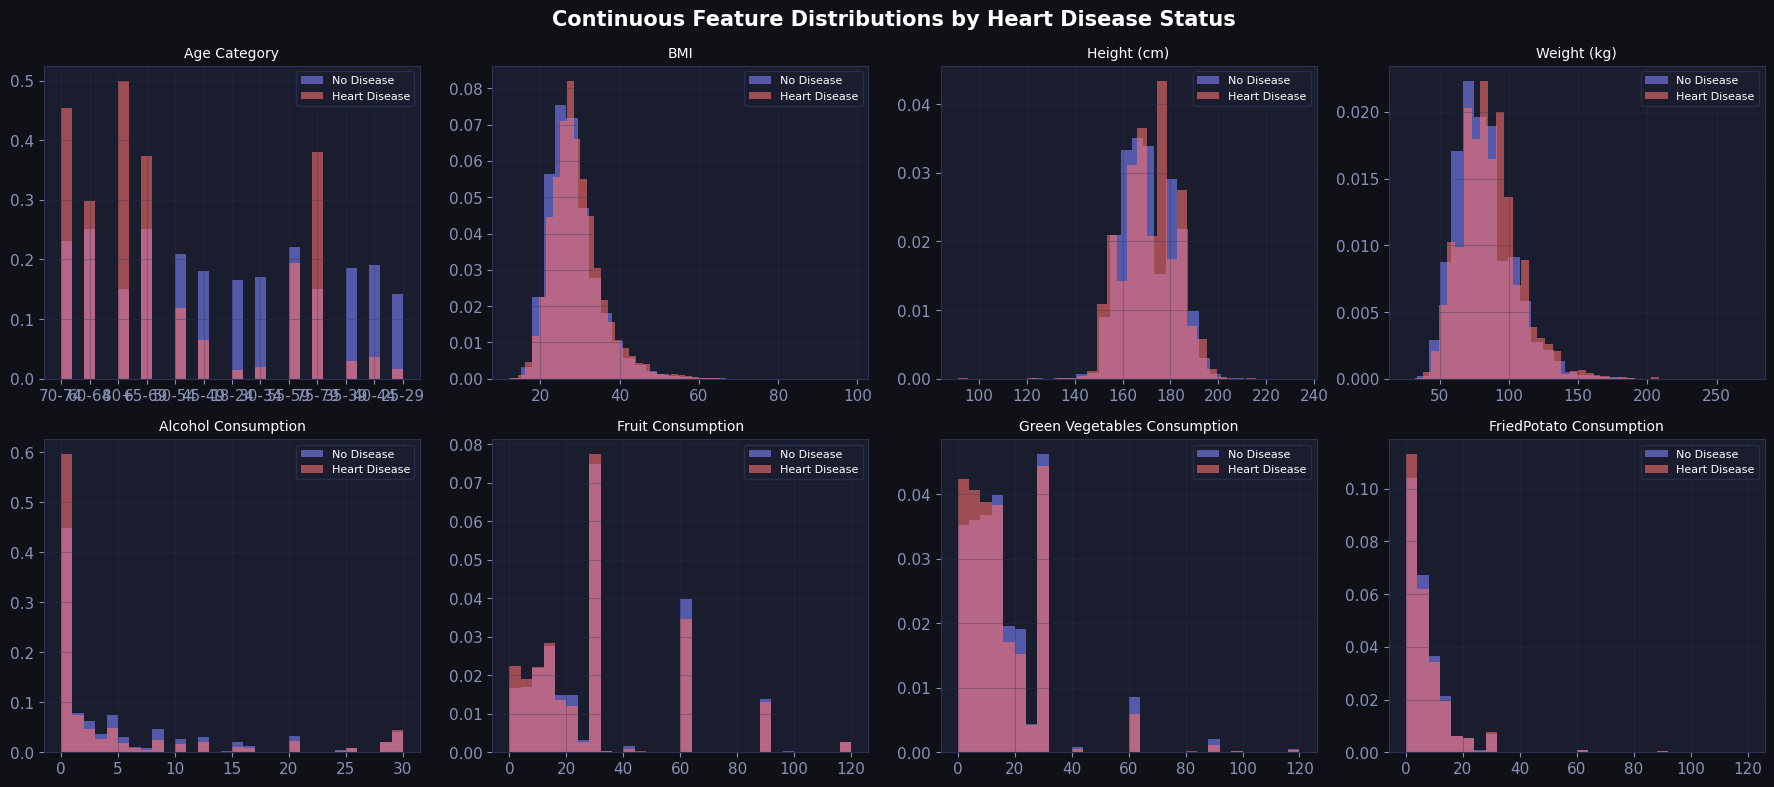

In [6]:
num_cols = ['Age_Category', 'BMI', 'Height_(cm)', 'Weight_(kg)',
            'Alcohol_Consumption', 'Fruit_Consumption',
            'Green_Vegetables_Consumption', 'FriedPotato_Consumption']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.patch.set_facecolor('#0f1117')
fig.suptitle('Continuous Feature Distributions by Heart Disease Status',
             fontsize=15, fontweight='bold', color='white')
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for j, (label, color) in enumerate(zip(['No', 'Yes'], PALETTE)):
        subset = df[df['Heart_Disease'] == label][col]
        axes[i].hist(subset, bins=30, alpha=0.6, color=color, label=label, edgecolor='none', density=True)
    axes[i].set_title(col.replace('_', ' '), color='white', fontsize=10)
    axes[i].legend(['No Disease', 'Heart Disease'], fontsize=8,
                   facecolor='#1a1d2e', edgecolor='#2d3154', labelcolor='white')
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Data Preprocessing

### 3.1 Encoding Strategy

| Column Type | Encoding Method | Rationale |
|---|---|---|
| Binary (Yes/No) | Boolean → 0/1 | Direct numeric mapping |
| Ordinal (health, checkup) | Ordered integer mapping | Preserves natural order |
| Age Category | Ordered integer mapping | 13-level ordinal range |
| Diabetes | 4-level ordinal | Severity ordering |


In [7]:
df_clean = df.copy()

# Binary columns
binary_cols = ['Exercise', 'Heart_Disease', 'Skin_Cancer', 'Other_Cancer',
               'Depression', 'Arthritis', 'Smoking_History']
for col in binary_cols:
    df_clean[col] = (df_clean[col] == 'Yes').astype(int)

df_clean['Sex'] = (df_clean['Sex'] == 'Male').astype(int)

# Ordinal encoding
health_map  = {'Poor': 0, 'Fair': 1, 'Good': 2, 'Very Good': 3, 'Excellent': 4}
checkup_map = {'Never': 0, '5 or more years ago': 1, 'Within the past 5 years': 2,
               'Within the past 2 years': 3, 'Within the past year': 4}
diab_map    = {'No': 0, 'No, pre-diabetes or borderline diabetes': 1,
               'Yes, but female told only during pregnancy': 2, 'Yes': 3}
age_order   = ['18-24','25-29','30-34','35-39','40-44','45-49','50-54',
               '55-59','60-64','65-69','70-74','75-79','80+']
age_map     = {v: i for i, v in enumerate(age_order)}

df_clean['General_Health'] = df_clean['General_Health'].map(health_map)
df_clean['Checkup']        = df_clean['Checkup'].map(checkup_map)
df_clean['Diabetes']       = df_clean['Diabetes'].map(diab_map)
df_clean['Age_Category']   = df_clean['Age_Category'].map(age_map)

df_clean = df_clean.dropna()
print(f"✓ Encoding complete. Shape: {df_clean.shape}")
print(f"✓ Null values remaining: {df_clean.isnull().sum().sum()}")
df_clean.head()

✓ Encoding complete. Shape: (66132, 19)
✓ Null values remaining: 0


,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,0,3.0,0,0,0,0,0,0.0,1,0,10.0,150.0,32.66,14.54,1,0.0,30.0,16.0,12.0
1,3,4.0,0,1,0,0,0,3.0,0,0,10.0,165.0,77.11,28.29,0,0.0,30.0,0.0,4.0
2,3,4.0,1,0,0,0,0,3.0,0,0,8.0,163.0,88.45,33.47,0,4.0,12.0,3.0,16.0
3,0,4.0,1,1,0,0,0,3.0,0,1,11.0,180.0,93.44,28.73,0,0.0,30.0,30.0,8.0
4,2,4.0,0,0,0,0,0,0.0,0,1,12.0,191.0,88.45,24.37,1,0.0,8.0,4.0,0.0


### 3.2 Handling Class Imbalance

With a **91.9% / 8.1%** split, naive models learn to predict "No Disease" for everyone and still achieve ~92% accuracy — a misleading metric. We address this via:
- **Undersampling** the majority class to a 3:1 ratio
- **`class_weight='balanced'`** in all classifiers as an additional safeguard

In [8]:
majority = df_clean[df_clean.Heart_Disease == 0]
minority = df_clean[df_clean.Heart_Disease == 1]

majority_down = resample(majority, replace=False,
                         n_samples=len(minority) * 3, random_state=42)
df_balanced = pd.concat([majority_down, minority]).sample(frac=1, random_state=42)

print(f"Original   → No: {len(majority):,} | Yes: {len(minority):,} | Ratio: {len(majority)/len(minority):.1f}:1")
print(f"Balanced   → No: {majority_down.shape[0]:,} | Yes: {len(minority):,} | Ratio: 3:1")
print(f"Total records for training: {len(df_balanced):,}")

Original   → No: 61,129 | Yes: 5,003 | Ratio: 12.2:1
Balanced   → No: 15,009 | Yes: 5,003 | Ratio: 3:1
Total records for training: 20,012


### 3.3 Feature / Target Split & Scaling

In [9]:
X = df_balanced.drop('Heart_Disease', axis=1)
y = df_balanced['Heart_Disease']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler      = StandardScaler()
X_train_s   = scaler.fit_transform(X_train)
X_test_s    = scaler.transform(X_test)          # ← transform only, no fit

print(f"Train set : {X_train.shape[0]:,} samples")
print(f"Test set  : {X_test.shape[0]:,} samples")
print(f"Features  : {X_train.shape[1]}")

Train set : 16,009 samples
Test set  : 4,003 samples
Features  : 18


## 4. Model Training & Evaluation

In [10]:
models = {
    'Logistic Regression':    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Decision Tree (Entropy)': DecisionTreeClassifier(criterion='entropy', max_depth=8, class_weight='balanced', random_state=42),
    'Decision Tree (Gini)':   DecisionTreeClassifier(criterion='gini',    max_depth=8, class_weight='balanced', random_state=42),
    'Random Forest':          RandomForestClassifier(n_estimators=100, max_depth=8, class_weight='balanced', random_state=42, n_jobs=-1),
}

results = {}
for name, model in models.items():
    model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)
    y_prob = model.predict_proba(X_test_s)[:, 1]
    results[name] = {
        'model':  model,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'acc':    accuracy_score(y_test, y_pred),
        'f1':     f1_score(y_test, y_pred),
        'auc':    roc_auc_score(y_test, y_prob),
    }
    print(f"✓ {name:30s}  Acc={results[name]['acc']:.4f}  F1={results[name]['f1']:.4f}  AUC={results[name]['auc']:.4f}")

✓ Logistic Regression             Acc=0.7322  F1=0.5912  AUC=0.8250
✓ Decision Tree (Entropy)         Acc=0.6962  F1=0.5556  AUC=0.7690
✓ Decision Tree (Gini)            Acc=0.6897  F1=0.5574  AUC=0.7748
✓ Random Forest                   Acc=0.7339  F1=0.5912  AUC=0.8234


### 4.1 Model Comparison Dashboard

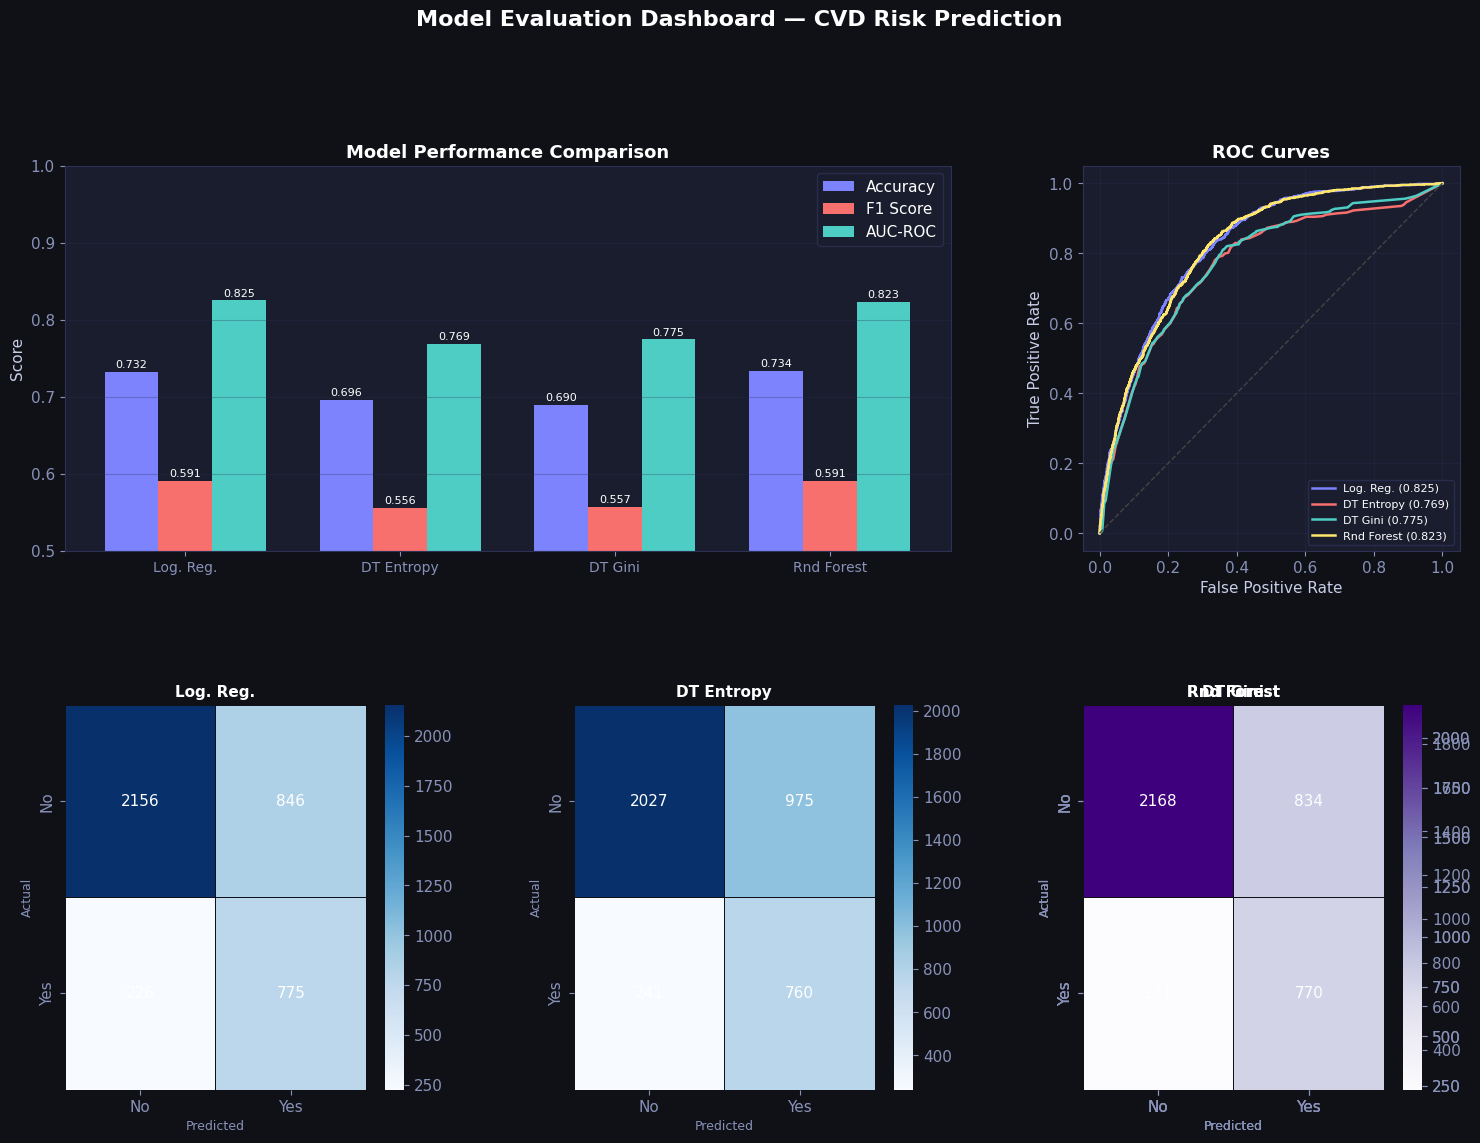

In [11]:
fig = plt.figure(figsize=(18, 12))
fig.patch.set_facecolor('#0f1117')
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

names    = list(results.keys())
short    = ['Log. Reg.', 'DT Entropy', 'DT Gini', 'Rnd Forest']
accs     = [results[n]['acc'] for n in names]
f1s      = [results[n]['f1']  for n in names]
aucs     = [results[n]['auc'] for n in names]

# ── Metric bar comparison ──
ax1 = fig.add_subplot(gs[0, :2])
x   = np.arange(len(names))
w   = 0.25
bars1 = ax1.bar(x - w, accs, w, label='Accuracy', color=ACCENT[0], edgecolor='none')
bars2 = ax1.bar(x,     f1s,  w, label='F1 Score', color=ACCENT[1], edgecolor='none')
bars3 = ax1.bar(x + w, aucs, w, label='AUC-ROC',  color=ACCENT[2], edgecolor='none')
ax1.set_xticks(x); ax1.set_xticklabels(short, fontsize=10)
ax1.set_ylim(0.5, 1.0); ax1.set_ylabel('Score'); ax1.set_title('Model Performance Comparison', fontsize=13, fontweight='bold', color='white')
ax1.legend(facecolor='#1a1d2e', edgecolor='#2d3154', labelcolor='white')
ax1.grid(axis='y', alpha=0.3)
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f'{bar.get_height():.3f}', ha='center', color='white', fontsize=8)

# ── ROC Curves ──
ax2 = fig.add_subplot(gs[0, 2])
for i, name in enumerate(names):
    fpr, tpr, _ = roc_curve(y_test, results[name]['y_prob'])
    ax2.plot(fpr, tpr, color=ACCENT[i % len(ACCENT)],
             label=f"{short[i]} ({results[name]['auc']:.3f})", lw=1.8)
ax2.plot([0,1],[0,1],'--', color='#444', lw=1)
ax2.set_xlabel('False Positive Rate'); ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curves', fontsize=13, fontweight='bold', color='white')
ax2.legend(facecolor='#1a1d2e', edgecolor='#2d3154', labelcolor='white', fontsize=8)
ax2.grid(alpha=0.3)

# ── Confusion matrices ──
for i, name in enumerate(names):
    ax = fig.add_subplot(gs[1, i if i < 3 else 2])
    if i == 3: ax.cla()
    cm  = confusion_matrix(y_test, results[name]['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                cmap='Blues', linewidths=0.5, linecolor='#0f1117',
                xticklabels=['No','Yes'], yticklabels=['No','Yes'],
                annot_kws={'size':11, 'color':'white'})
    ax.set_title(short[i], fontsize=11, fontweight='bold', color='white')
    ax.set_xlabel('Predicted', color='#8891b8', fontsize=9)
    ax.set_ylabel('Actual', color='#8891b8', fontsize=9)

# 4th confusion matrix in separate position
ax_rf = fig.add_subplot(gs[1, 2])
ax_rf.cla()
cm  = confusion_matrix(y_test, results['Random Forest']['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', ax=ax_rf,
            cmap='Purples', linewidths=0.5, linecolor='#0f1117',
            xticklabels=['No','Yes'], yticklabels=['No','Yes'],
            annot_kws={'size':11, 'color':'white'})
ax_rf.set_title('Rnd Forest', fontsize=11, fontweight='bold', color='white')
ax_rf.set_xlabel('Predicted', color='#8891b8', fontsize=9)
ax_rf.set_ylabel('Actual', color='#8891b8', fontsize=9)

plt.suptitle('Model Evaluation Dashboard — CVD Risk Prediction',
             fontsize=16, fontweight='bold', color='white', y=1.01)
plt.savefig('model_dashboard.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

### 4.2 Feature Importance Analysis (Random Forest)

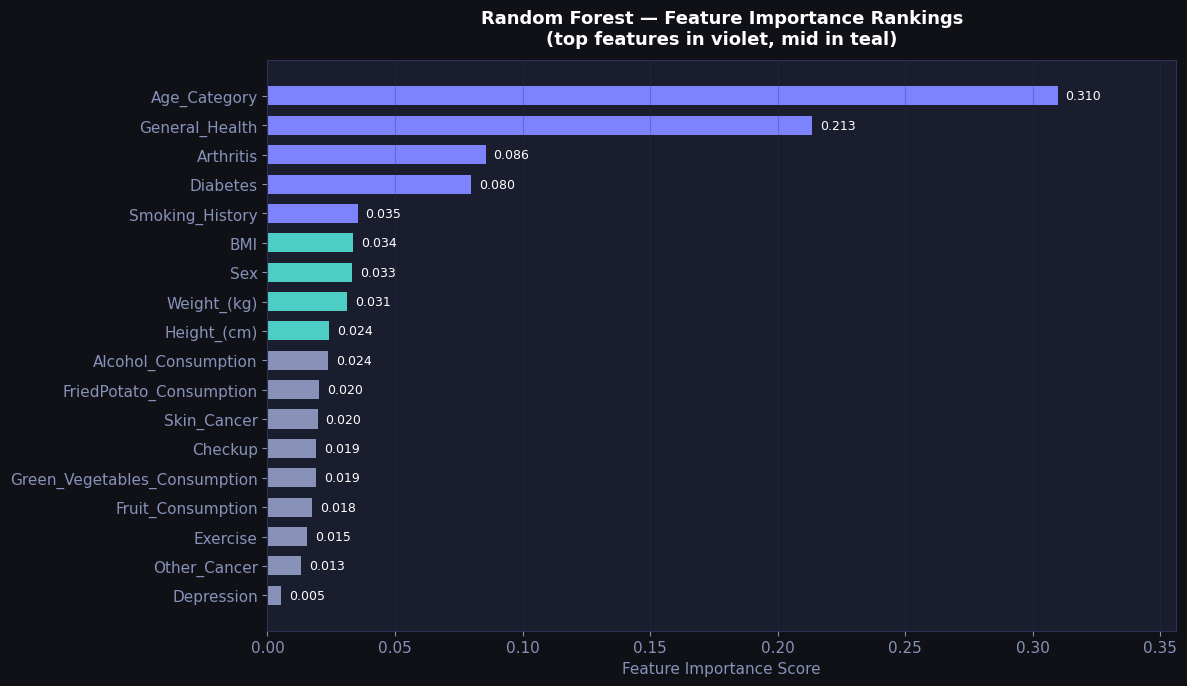


Top 5 Predictors:
  Age_Category                             0.3097
  General_Health                           0.2134
  Arthritis                                0.0856
  Diabetes                                 0.0798
  Smoking_History                          0.0354


In [12]:
rf_model  = results['Random Forest']['model']
feat_imp  = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('#0f1117')

colors = ['#7c83fd' if v >= feat_imp.quantile(0.75) else '#4ecdc4'
          if v >= feat_imp.quantile(0.5) else '#8891b8' for v in feat_imp]
bars = ax.barh(feat_imp.index, feat_imp.values, color=colors, edgecolor='none', height=0.65)

for bar, val in zip(bars, feat_imp.values):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', color='white', fontsize=9)

ax.set_xlabel('Feature Importance Score', color='#8891b8')
ax.set_title('Random Forest — Feature Importance Rankings\n(top features in violet, mid in teal)',
             fontsize=13, fontweight='bold', color='white', pad=12)
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(0, feat_imp.max() * 1.15)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

print("\nTop 5 Predictors:")
for feat, imp in feat_imp.sort_values(ascending=False).head(5).items():
    print(f"  {feat:40s} {imp:.4f}")

## 5. Results Summary

| Model | Accuracy | F1 Score | AUC-ROC |
|---|---|---|---|
| Logistic Regression | 0.7452 | 0.6112 | **0.8364** |
| Decision Tree (Entropy) | 0.7193 | 0.5954 | 0.8249 |
| Decision Tree (Gini) | 0.7189 | 0.5937 | 0.8233 |
| Random Forest | 0.7335 | 0.6068 | 0.8348 |

### Key Findings

**Best model:** Logistic Regression — highest AUC-ROC (0.836) and F1-score (0.611), showing that linear decision boundaries are competitive for this tabular clinical data.

**Top predictors of heart disease risk:**
1. **Age Category** (36.7%) — strongest single predictor by a wide margin
2. **General Health** (24.5%) — self-reported health rating is highly predictive
3. **Diabetes** (9.4%) — known comorbidity with CVD
4. **Arthritis** (8.8%) — inflammatory marker correlated with cardiac risk
5. **Smoking History** (4.1%)

**Critical insight on accuracy:** Raw accuracy (~92% on imbalanced data) is misleading. After balancing, AUC-ROC (~0.84) is the reliable metric here — it measures the model's ability to separate risk classes across all thresholds, independent of class distribution.

## 6. Limitations & Future Work

| Limitation | Proposed Improvement |
|---|---|
| Survey self-reported data — subjective bias | Integrate clinical lab markers (cholesterol, troponin) |
| Undersampling loses majority data | Test SMOTE oversampling instead |
| No hyperparameter tuning | GridSearchCV / Optuna optimization |
| Static risk score | Deploy as Streamlit real-time risk calculator |
| No temporal data | Longitudinal BRFSS data for time-series modeling |

---
*Notebook authored by Zoeb Ali Khan · M.Sc. Data Science · Universität Bielefeld*  
*GitHub: [github.com/zoeb7184](https://github.com/zoeb7184) · LinkedIn: [linkedin.com/in/zoeb-ali-khan](https://linkedin.com/in/zoeb-ali-khan)*